In [7]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.model_selection import train_test_split
from google.colab import files

import warnings
warnings.filterwarnings('ignore')

In [9]:
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# print(f"Fichier '{filename}' uploadé!")
df = pd.read_csv('/content/drive/MyDrive/python/cleanedDataset.csv')
print("Dataset loaded!")

Dataset loaded!


In [10]:
df.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear
0,41,1,2,1,2,0,2,8,0
1,49,0,1,8,1,1,1,10,3
2,37,1,2,2,2,1,2,7,3
3,33,0,1,3,4,0,1,8,3
4,27,0,2,2,1,1,1,6,3


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Age                    1470 non-null   int64
 1   Attrition              1470 non-null   int64
 2   BusinessTravel         1470 non-null   int64
 3   DistanceFromHome       1470 non-null   int64
 4   Education              1470 non-null   int64
 5   Gender                 1470 non-null   int64
 6   MaritalStatus          1470 non-null   int64
 7   TotalWorkingYears      1470 non-null   int64
 8   TrainingTimesLastYear  1470 non-null   int64
dtypes: int64(9)
memory usage: 103.5 KB


In [12]:
y = df['Attrition']
X = df.drop('Attrition', axis=1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
def get_original_feature_names(columns):
    return columns.str.split('_').str[0]

# Features Analysis

Tree-based Feature Importance

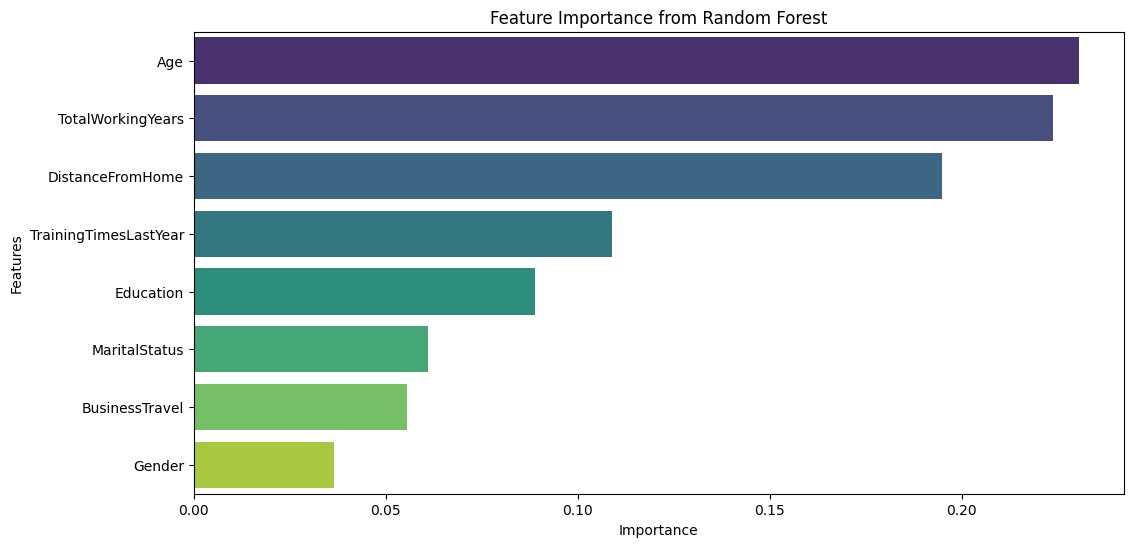

In [14]:
# Fit RF
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

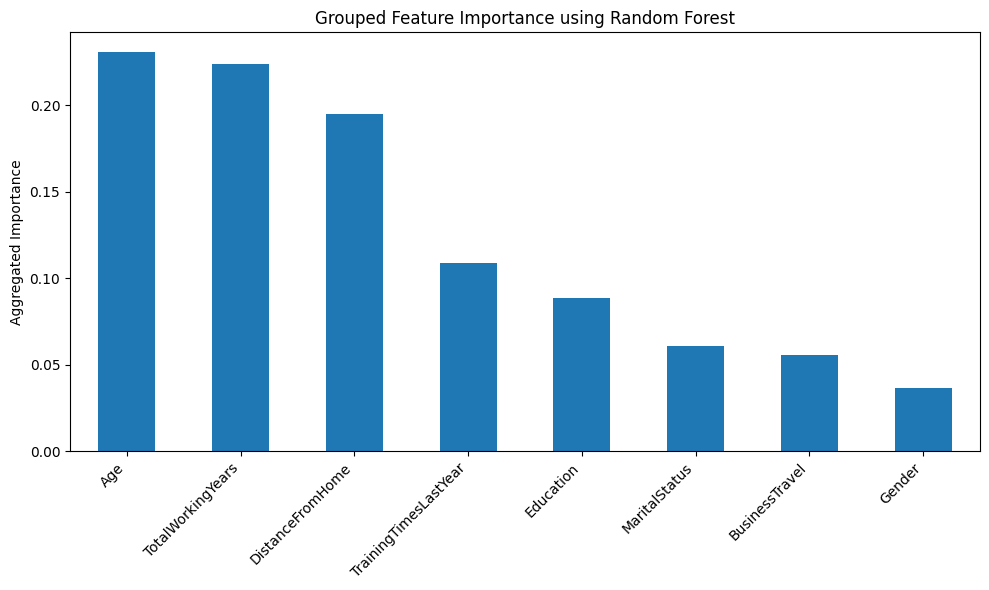

In [15]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

rf_grouped = (
    rf_importance
    .groupby(get_original_feature_names(rf_importance.index))
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
rf_grouped.plot(kind='bar')
plt.title("Grouped Feature Importance using Random Forest")
plt.ylabel("Aggregated Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Mutual Information

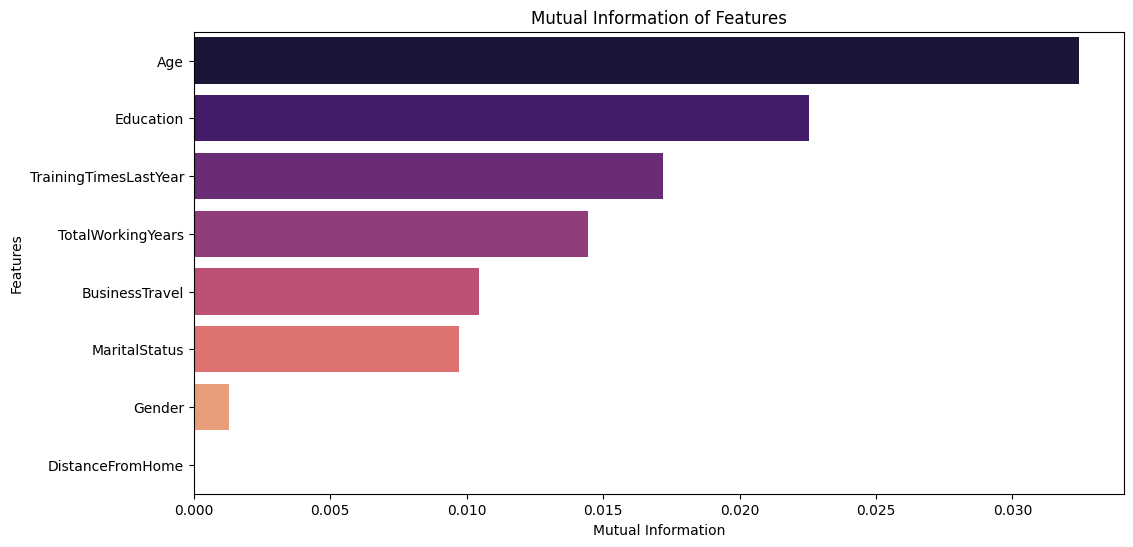

In [16]:
# This method shows how much each feature is related to the target, regardless of the model.
mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='magma')
plt.title("Mutual Information of Features")
plt.xlabel("Mutual Information")
plt.ylabel("Features")
plt.show()

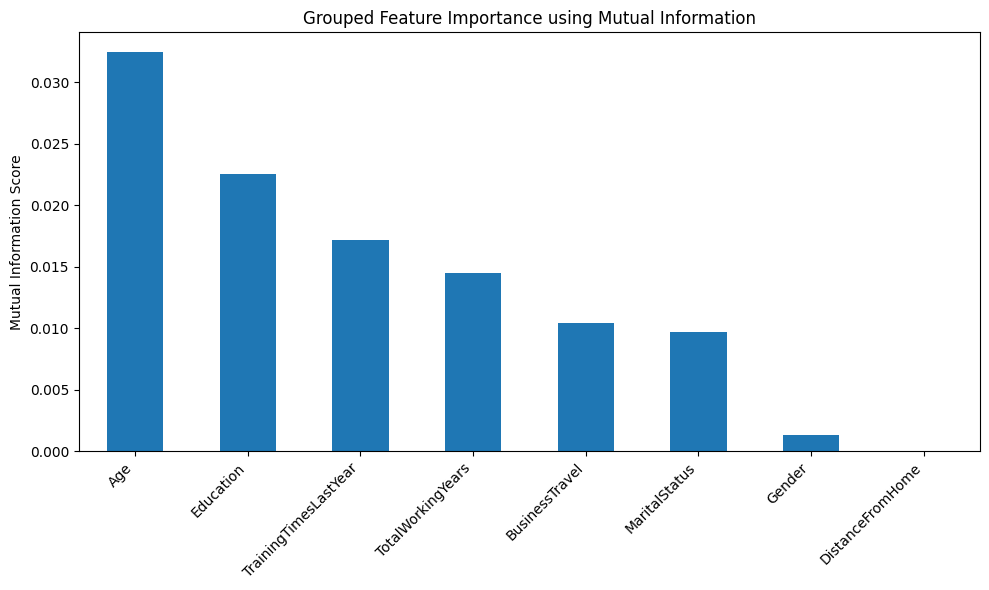

In [17]:
mi = mutual_info_classif(X, y, random_state=42)

mi_series = pd.Series(mi, index=X.columns)

mi_grouped = (
    mi_series
    .groupby(get_original_feature_names(mi_series.index))
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
mi_grouped.plot(kind='bar')
plt.title("Grouped Feature Importance using Mutual Information")
plt.ylabel("Mutual Information Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# lasso

In [18]:
# Lasso logistic regression
lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=5000)
lasso.fit(X_train, y_train)

# Features with non-zero coefficients
selected_features_lasso = X_train.columns[(lasso.coef_ != 0).ravel()]
print("Features selected by Lasso:", list(selected_features_lasso))
print(len(list(selected_features_lasso)))

Features selected by Lasso: ['Age', 'BusinessTravel', 'DistanceFromHome', 'Education', 'Gender', 'MaritalStatus', 'TotalWorkingYears', 'TrainingTimesLastYear']
8


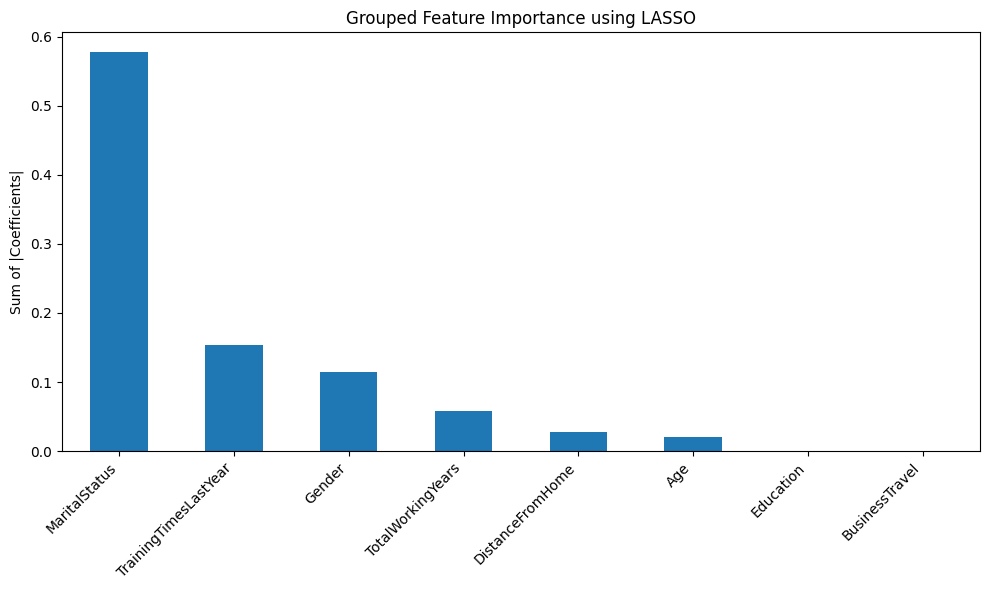

In [19]:
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

lasso.fit(X, y)

lasso_coef = pd.Series(
    abs(lasso.coef_[0]),
    index=X.columns
)

lasso_grouped = (
    lasso_coef
    .groupby(get_original_feature_names(lasso_coef.index))
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
lasso_grouped.plot(kind='bar')
plt.title("Grouped Feature Importance using LASSO")
plt.ylabel("Sum of |Coefficients|")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# RFE

In [29]:
# Using logistic regression as estimator
estimator = LogisticRegression(solver='liblinear', random_state=42)

# RFE: select top 10 features
rfe = RFE(estimator=estimator, n_features_to_select=10)
rfe.fit(X_train, y_train)

selected_features_rfe = X_train.columns[rfe.support_]
print("Features selected by RFE:", list(selected_features_rfe))
print(len(list(selected_features_rfe)))

Features selected by RFE: ['Age', 'BusinessTravel', 'DistanceFromHome', 'Education', 'Gender', 'MaritalStatus', 'TotalWorkingYears', 'TrainingTimesLastYear']
8


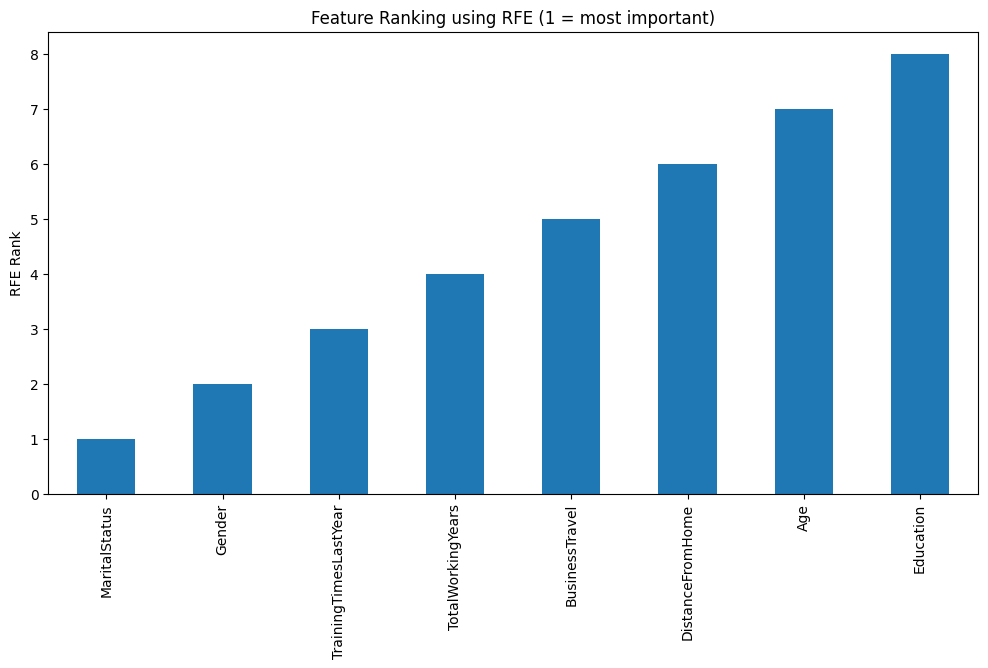

In [21]:
model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=1)
rfe.fit(X, y)

rfe_ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()

plt.figure(figsize=(12,6))
rfe_ranking.plot(kind='bar')
plt.title("Feature Ranking using RFE (1 = most important)")
plt.ylabel("RFE Rank")
plt.show()

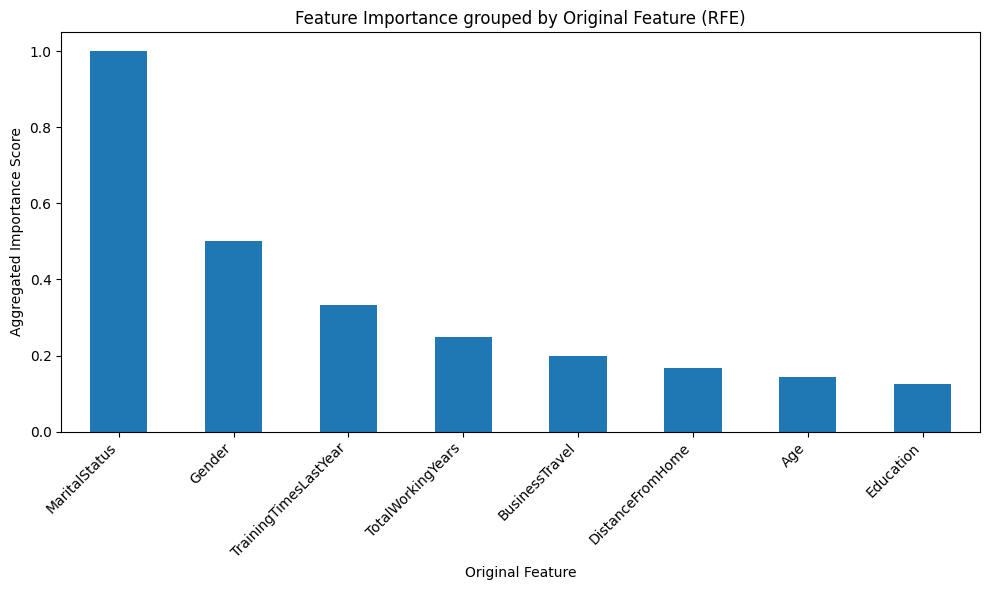

In [22]:
rfe_ranking = pd.Series(rfe.ranking_, index=X.columns)
rfe_importance = 1 / rfe_ranking
original_feature = rfe_importance.index.str.split('_').str[0]
rfe_grouped = (
    rfe_importance
    .groupby(original_feature)
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
rfe_grouped.plot(kind='bar')
plt.title("Feature Importance grouped by Original Feature (RFE)")
plt.ylabel("Aggregated Importance Score")
plt.xlabel("Original Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


PCA

In [23]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)
print("Explained variance by each component:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))
print("Number of components selected:", pca.n_components_)

Explained variance by each component: [0.56986242 0.30764459 0.10438014]
Total variance explained: 0.9818871483540421
Number of components selected: 3


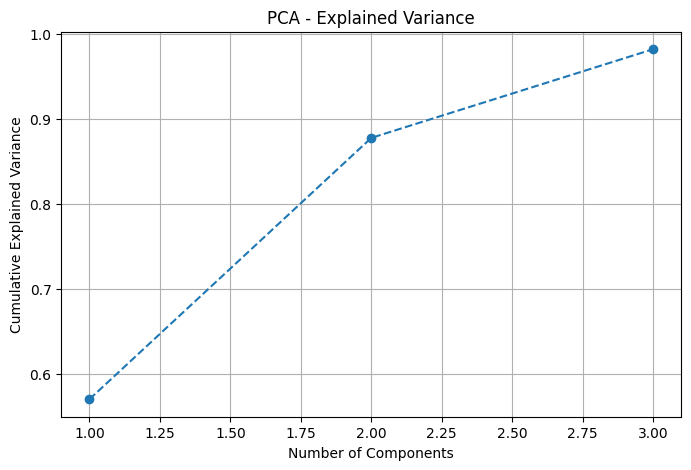

In [24]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.grid(True)
plt.show()

In [25]:
pca = PCA()
pca.fit(X)

loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(X.shape[1])],
                        index=X.columns)

original_features = get_original_feature_names(loadings.index.to_series())
loadings['OriginalFeature'] = original_features

grouped_loadings = loadings.groupby('OriginalFeature').apply(lambda df: df.drop(columns='OriginalFeature').abs().sum())
grouped_loadings['TotalContribution'] = grouped_loadings.sum(axis=1)

grouped_loadings = grouped_loadings.sort_values('TotalContribution', ascending=False)

top_table = grouped_loadings.sort_values('TotalContribution', ascending=False).round(3)
print(top_table.to_string())

                         PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8  TotalContribution
OriginalFeature                                                                                 
Age                    0.784  0.006  0.620  0.000  0.023  0.007  0.001  0.001              1.442
TotalWorkingYears      0.620  0.005  0.784  0.007  0.001  0.002  0.003  0.003              1.425
MaritalStatus          0.006  0.001  0.002  0.006  0.039  0.986  0.153  0.060              1.254
BusinessTravel         0.002  0.002  0.002  0.011  0.003  0.151  0.987  0.045              1.203
Gender                 0.002  0.000  0.002  0.018  0.008  0.066  0.035  0.997              1.128
Education              0.019  0.003  0.013  0.040  0.998  0.038  0.009  0.005              1.125
TrainingTimesLastYear  0.003  0.006  0.006  0.999  0.039  0.010  0.010  0.017              1.093
DistanceFromHome       0.002  1.000  0.007  0.006  0.002  0.002  0.002  0.000              1.021


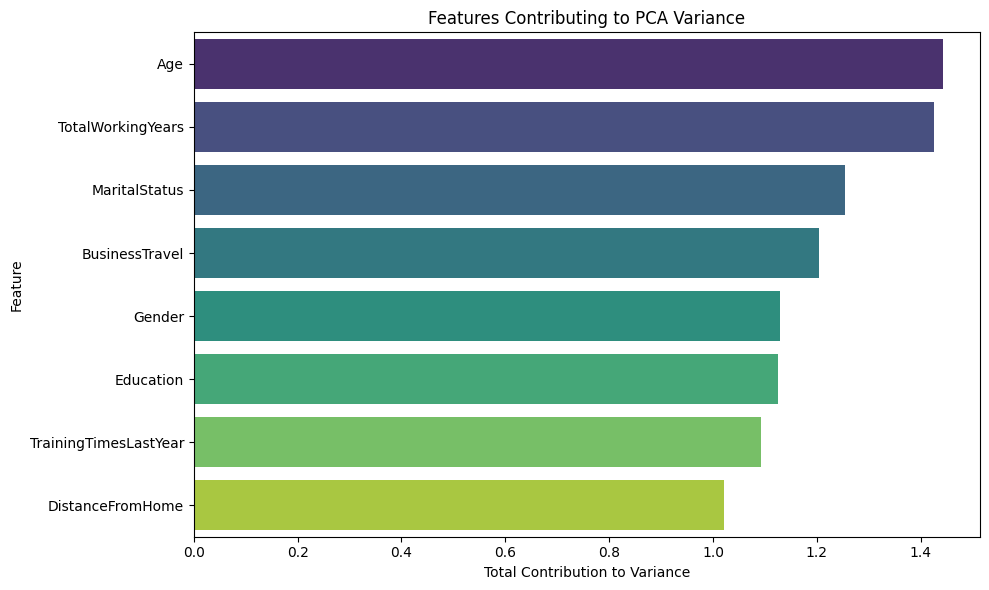

In [26]:
top_features = grouped_loadings.sort_values('TotalContribution', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='TotalContribution', y=top_features.index, data=top_features, palette='viridis')
plt.title(f'Features Contributing to PCA Variance')
plt.xlabel('Total Contribution to Variance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


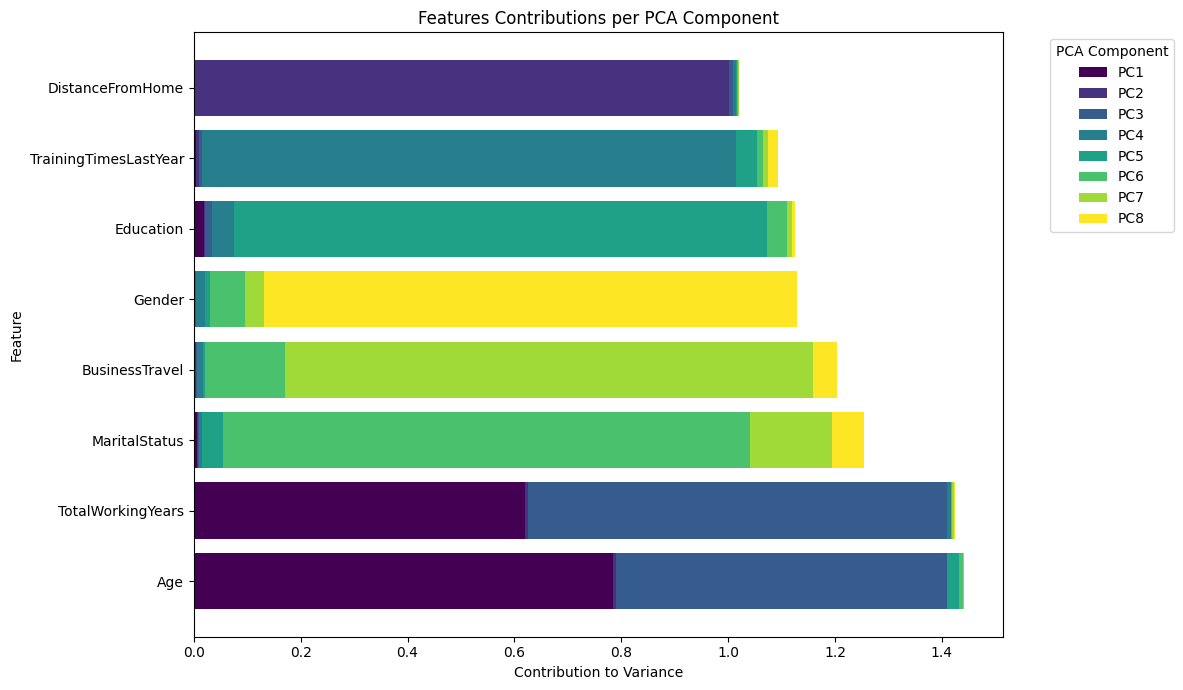

In [27]:
component_cols = [col for col in grouped_loadings.columns if col != 'TotalContribution']

top_features = grouped_loadings.sort_values('TotalContribution', ascending=False)

#Prepare data for stacked bar plot
top_features_per_component = top_features[component_cols]

plt.figure(figsize=(12,7))
bottom = np.zeros(len(top_features_per_component))
colors = plt.cm.viridis(np.linspace(0,1,len(component_cols)))

for i, col in enumerate(component_cols):
    plt.barh(top_features_per_component.index,
             top_features_per_component[col],
             left=bottom,
             color=colors[i],
             label=col)
    bottom += top_features_per_component[col].values

plt.xlabel('Contribution to Variance')
plt.ylabel('Feature')
plt.title(f'Features Contributions per PCA Component')
plt.legend(title='PCA Component', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


ALL

In [28]:
comparison = pd.DataFrame({
    "LASSO": lasso_grouped,
    "RandomForest": rf_grouped,
    "MutualInformation": mi_grouped,
    "RFE": rfe_grouped
}).fillna(0)

comparison.sort_values(
    by=["RandomForest", "MutualInformation", "LASSO", "RFE"],
    ascending=False
).head(10)


,LASSO,RandomForest,MutualInformation,RFE
Age,0.020971,0.230659,0.032457,0.142857
TotalWorkingYears,0.058306,0.223724,0.014463,0.250000
DistanceFromHome,0.027483,0.194952,0.000000,0.166667
TrainingTimesLastYear,0.153173,0.108831,0.017205,0.333333
Education,0.000000,0.088773,0.022547,0.125000
MaritalStatus,0.577315,0.060908,0.009719,1.000000
BusinessTravel,0.000000,0.055559,0.010447,0.200000
Gender,0.114027,0.036594,0.001305,0.500000
